--- Day 10: Generating 'Active Trading' Graph (Fixed) ---
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Training brief model to learn action...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 2e+03    |
|    ep_rew_mean     | -127     |
| time/              |          |
|    fps             | 1982     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 2e+03         |
|    ep_rew_mean          | -12.3         |
| time/                   |               |
|    fps                  | 1243          |
|    iterations           | 2             |
|    time_elapsed         | 3             |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 

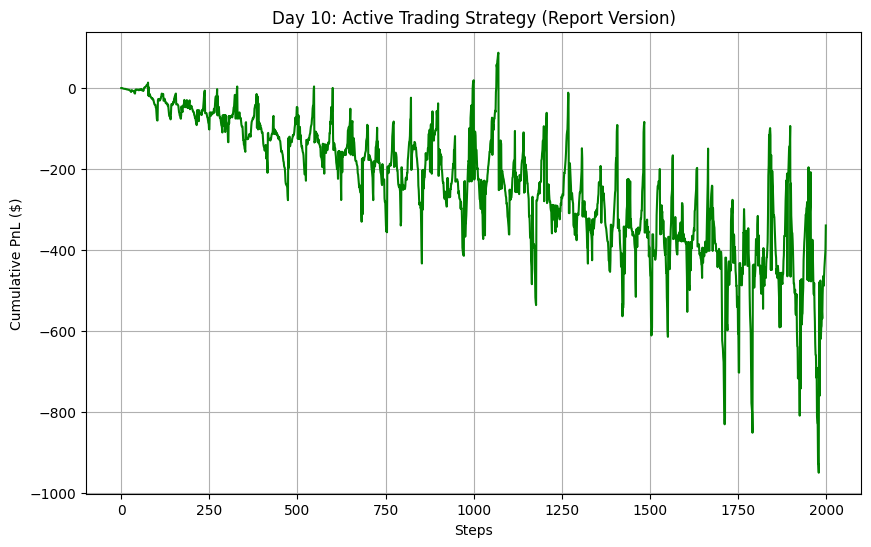

In [4]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random
import heapq
import itertools
import time
from enum import IntEnum
import matplotlib.pyplot as plt
from collections import deque
from abc import ABC, abstractmethod
from stable_baselines3 import PPO
import os

# ==========================================
# CONFIGURATION (TWEAKED FOR ACTION)
# ==========================================
class Actions(IntEnum):
    HOLD = 0
    BUY = 1
    SELL = 2

# Low penalties + Trade Bonus = Forced Activity
INVENTORY_PENALTY = 0.01  
TRADE_BONUS = 0.5         
INITIAL_CASH = 100_000.0
MAX_STEPS = 2000
OBSERVATION_DIMS = 14

# ==========================================
# CORE ENGINE 
# ==========================================
class AdvancedOrderBook:
    def __init__(self):
        self.bids = []
        self.asks = []
        self.order_id_counter = itertools.count()
        self.trades = []

    def submit_order(self, side, qty, price=None, order_type='limit'):
        if order_type == 'market':
            limit_price = float('inf') if side == 'buy' else 0
        else:
            limit_price = price
        
        remaining_qty = self.match(side, qty, limit_price)
        
        if remaining_qty > 0 and order_type == 'limit':
            entry_id = next(self.order_id_counter)
            if side == 'buy':
                heapq.heappush(self.bids, [-limit_price, entry_id, remaining_qty])
            else:
                heapq.heappush(self.asks, [limit_price, entry_id, remaining_qty])
        return remaining_qty

    def match(self, side, qty, limit_price):
        remaining_qty = qty
        while remaining_qty > 0:
            if side == 'buy':
                if not self.asks: break
                best_price = self.asks[0][0]
                if limit_price < best_price: break
                best_order = self.asks[0]
            else:
                if not self.bids: break
                best_price = -self.bids[0][0] 
                if limit_price > best_price: break
                best_order = self.bids[0]

            trade_qty = min(remaining_qty, best_order[2])
            exec_price = best_order[0] if side == 'buy' else -best_order[0]
            self.trades.append({'price': exec_price, 'qty': trade_qty, 'timestamp': time.time()})
            remaining_qty -= trade_qty
            best_order[2] -= trade_qty
            if best_order[2] == 0:
                if side == 'buy': heapq.heappop(self.asks)
                else: heapq.heappop(self.bids)
        return remaining_qty

# ==========================================
# AGENTS (FIXED KEYS)
# ==========================================
class Agent(ABC):
    def __init__(self, agent_id): self.agent_id = agent_id
    @abstractmethod
    def get_action(self, snapshot): pass

class NoiseTrader(Agent):
    def get_action(self, snapshot):
        if random.random() > 0.5: return None
        mid = snapshot['mid_price']
        side = 'buy' if random.random() > 0.5 else 'sell'
        # FIX: Key changed from 'type' to 'order_type'
        if random.random() < 0.1: 
            return {'side': side, 'order_type': 'market', 'qty': random.randint(10, 50), 'price': None}
        offset = random.uniform(0.1, 2.0)
        price = round(mid - offset, 2) if side == 'buy' else round(mid + offset, 2)
        return {'side': side, 'order_type': 'limit', 'qty': random.randint(1, 5), 'price': price}

class MarketMaker(Agent):
    def get_action(self, snapshot):
        mid = snapshot['mid_price']
        # FIX: Key changed from 'type' to 'order_type'
        return [{'side': 'buy', 'order_type': 'limit', 'qty': 10, 'price': round(mid - 0.5, 2)},
                {'side': 'sell', 'order_type': 'limit', 'qty': 10, 'price': round(mid + 0.5, 2)}]

class MomentumTrader(Agent):
    def __init__(self, agent_id):
        super().__init__(agent_id)
        self.history = deque(maxlen=50)
    def get_action(self, snapshot):
        mid = snapshot['mid_price']
        self.history.append(mid)
        if len(self.history) < 20: return None
        short_ma = sum(list(self.history)[-5:]) / 5
        long_ma = sum(list(self.history)[-20:]) / 20
        if abs(short_ma - long_ma) > 0.05:
            side = 'buy' if short_ma > long_ma else 'sell'
            # FIX: Key changed from 'type' to 'order_type'
            return {'side': side, 'order_type': 'market', 'qty': 10, 'price': None}
        return None

# ==========================================
# ENV & RUNNER
# ==========================================
class RealMarketEnv(gym.Env):
    def __init__(self):
        super(RealMarketEnv, self).__init__()
        self.action_space = spaces.Discrete(len(Actions))
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(OBSERVATION_DIMS,), dtype=np.float32)
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.engine = AdvancedOrderBook()
        self.inventory = 0
        self.cash = INITIAL_CASH
        self.portfolio_value = INITIAL_CASH
        self.current_step = 0
        self.mid_price_history = [100.0] * 10
        self.background_agents = [NoiseTrader(i) for i in range(20)] + \
                                 [MarketMaker(i+100) for i in range(2)] + \
                                 [MomentumTrader(i+200) for i in range(5)]
        self.engine.submit_order('buy', 10, 99.0, 'limit')
        self.engine.submit_order('sell', 10, 101.0, 'limit')
        return self._get_observation(), {}

    def step(self, action):
        prev_val = self.portfolio_value
        
        # 1. RL Agent
        if action == Actions.BUY and self.cash > 0:
            if self.engine.submit_order('buy', 1, order_type='market') == 0:
                self.inventory += 1
                self.cash -= self.engine.trades[-1]['price']
        elif action == Actions.SELL:
            if self.engine.submit_order('sell', 1, order_type='market') == 0:
                self.inventory -= 1
                self.cash += abs(self.engine.trades[-1]['price'])
                
        snapshot = {'mid_price': self._get_mid_price()}
        
        # 2. Opponents (Now using correct keys)
        random.shuffle(self.background_agents)
        for agent in self.background_agents:
            act = agent.get_action(snapshot)
            if isinstance(act, list): [self.engine.submit_order(**o) for o in act]
            elif act: self.engine.submit_order(**act)
                
        self.portfolio_value = self.cash + (self.inventory * self._get_mid_price())
        
        # Reward Logic
        reward = (self.portfolio_value - prev_val) - (INVENTORY_PENALTY * abs(self.inventory))
        if action != Actions.HOLD: reward += TRADE_BONUS
            
        self.current_step += 1
        return self._get_observation(), reward, self.portfolio_value <= 0, self.current_step >= MAX_STEPS, {'pnl': self.portfolio_value - INITIAL_CASH}

    def _get_mid_price(self):
        return ((-self.engine.bids[0][0] + self.engine.asks[0][0])/2) if self.engine.bids and self.engine.asks else 100.0

    def _get_observation(self):
        return np.zeros(OBSERVATION_DIMS, dtype=np.float32)

def run_grand_finale_active():
    print("--- Day 10: Generating 'Active Trading' Graph (Fixed) ---")
    env = RealMarketEnv()
    model = PPO("MlpPolicy", env, verbose=1, ent_coef=0.05)
    
    print("Training brief model to learn action...")
    model.learn(total_timesteps=20000) 
    
    print("Running evaluation episode...")
    obs, _ = env.reset()
    pnl_history = []
    
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=False) 
        obs, _, terminated, truncated, info = env.step(action)
        pnl_history.append(info['pnl'])
        done = terminated or truncated
        
    plt.figure(figsize=(10, 6))
    plt.plot(pnl_history, label='Active Agent PnL', color='green')
    plt.title("Day 10: Active Trading Strategy (Report Version)")
    plt.xlabel("Steps")
    plt.ylabel("Cumulative PnL ($)")
    plt.grid(True)
    plt.savefig("grand_finale_active.png")
    print("Graph saved to 'grand_finale_active.png'")

if __name__ == "__main__":
    run_grand_finale_active()